## Import

In [1]:
import numpy as np
import scipy
from scipy import signal
from scipy.signal import hilbert
from scipy import integrate

try:
    from scipy.integrate import simps
except ImportError:
    from scipy.integrate import simpson

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")


# VERY CAREFULLY not to delete other folders!
if os.path.isdir("fid_data"):
    shutil.rmtree("fid_data")
    print("The fid_data folder is deleted and created again")
    print(" ")

os.makedirs("fid_data", exist_ok=True)


os.makedirs("fid_data/drude", exist_ok=True)
os.makedirs("fid_data/drude/data", exist_ok=True)
os.makedirs("fid_data/drude/data/current", exist_ok=True)
os.makedirs("fid_data/drude/data/m", exist_ok=True)
os.makedirs("fid_data/drude/data/abc", exist_ok=True)
os.makedirs("fid_data/drude/data/tau", exist_ok=True)
os.makedirs("fid_data/drude/data/n_ex", exist_ok=True)
os.makedirs("fid_data/drude/ims", exist_ok=True)

os.makedirs("fid_data/drude/ims/png", exist_ok=True)
os.makedirs("fid_data/drude/ims/pdf", exist_ok=True)

os.makedirs("fid_data/fid", exist_ok=True)
os.makedirs("fid_data/fid/z", exist_ok=True)
os.makedirs("fid_data/fid/z/data", exist_ok=True)
os.makedirs("fid_data/fid/z/ims", exist_ok=True)
os.makedirs("fid_data/fid/z/ims/png", exist_ok=True)
os.makedirs("fid_data/fid/z/ims/pdf", exist_ok=True)


volume = 160.1 # для Si в A^3

# m0_cut_1 = 10500  # 21 fs: for exp fit
# m0_cut_2 = 6250   # 12.5 fs: for full drude fit (needs to be adjusted in accordance to z_pump energy)
# # 3749 (7.5 fms), 5999 (12 fms)

# m0_cut_3 = 5250 # 10.5 fs: start of integration for Δk analysis. half of probe pulse duration

# In[116]:


plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg') for server (not necessary)
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())


## exp fit drude funcs

In [2]:
def drude_current_v1(dummy_t, j0, j_final, tau):

    # tau = 6.65
    dt = 0.002

    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_1 = int(500*t_probe)

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_1:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

In [3]:
def drude_exp_fit_v2_pump(dummy_t, j0, j_final, tau):


    t_probe, t_pump = get_pulse_durations(folder)
    # m0_cut_4 = int(500*(t_probe+t_pump)/2) 
    
    # tau = 6.65
    dt = 0.002

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_4:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

## extract

In [4]:
def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

# def extract_a_num(s):
#     start = s.index('_a') + 2
#     end = s.index('_', start)
#     return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return float(match.group(1).replace("d", "e"))

def extract_amorphous_value(name):
    tokens = name.split("_")
    for i, token in enumerate(tokens):
        if token == "amorphous" and i + 1 < len(tokens):
            return float(tokens[i + 1])

In [5]:
def get_n_excited_electrons(folder):

    output_probe = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/probe_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_probe = nelec[-1]

    output_pump = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/pump_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_pump = nelec[-1]


    output_both = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/both_pulses_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_both = nelec[-1]


    
    gs_file = glob.glob(folder + '/Si_gs*')

    with open(gs_file[0], 'r') as file:
        lines = file.readlines()
    
    for line in lines:
        if 'al(1:3)' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            factor = nums[0]*nums[1]*nums[2]

    return output_both/factor, output_pump/factor, output_probe/factor

In [6]:
def get_pulse_durations(folder):

    pulses_file = glob.glob(folder + '/Si_rt_both*')
    
    with open(pulses_file[0], 'r') as file:
            lines = file.readlines()
        
    for line in lines:
        if 'tw1' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_probe = nums[0]
    
    for line in lines:
        if 'tw2' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_pump = nums[0]

    return t_probe, t_pump

## sorted folders

In [7]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
folders = [f for f in folders 
           if f.startswith('c') 
           and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data'))]
           # and not os.path.isdir(os.path.join(f, 'restart'))]


# print(folders)


if "amorphous" in folders[0]:
    sorted_folders = sorted(folders, key=extract_amorphous_value, reverse=True)

else:
    sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_i_num(s)))

print("Sorted folders are:")
for f in sorted_folders:
    print(f)
print(" ")

Sorted folders are:
c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV
 


## drude

In [8]:
def effecive_mass_model(alpha, a, b, c):
    return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [9]:
delta_start_drude_fit = 3400

def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    t = data_both['time_fs']
    El_f_probe_x = data_both['E_ext_x']
    
    
    step_dt = 0.002
    


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    
    
    dt = np.diff(t, prepend=t[0])
    
    
    alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
    fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
    alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_2:])         # сетка времени
    E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0

    # if folder=='c333_amorphous_0.93_s0.050_r18_k16_a1_i804_t9_p4d10_2d11':
    #     for k in range(len(t_array)-1):
    #         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/5 + alpha_fit[k] * E_array[k])

    # else: 
    #     for k in range(len(t_array)-1):
    #         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
    for k in range(len(t_array)-1):
            j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])
    
    return j_euler[::1]

0.003762128646856511 0.6185492679852342 11.706811700363472
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV drude fit plots are completed
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV drude fit current data saving in csv format is completed


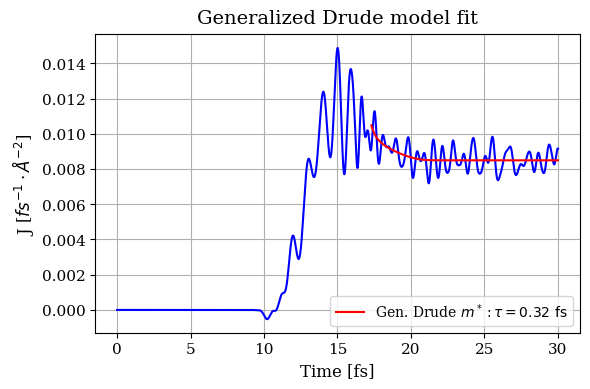

In [10]:
new_taus = []
new_j_finals = []
arr_abc = []

alphas_start = []
alphas_final = []

    
folder = sorted_folders[0]

j=0
num_folder=0
for folder in sorted_folders:

    j=j+1
    num_folder=num_folder+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    dt = np.diff(t, prepend=t[0])
    
    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    alphas_start.append(a_start)
    alphas_final.append(a_fin)
    
    
    # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)
    
    
    fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
    delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x
    
    # t_array_cut = np.array(t[m0_cut_2:])[::50]
    # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
    # # (dummy_t, j0, fit_alpha, j_final)
    # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
    # # print(len(t_array_cut), len(j_exp))
    # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
    # j0, fit_alpha = popt
    # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)
    
    plt.figure(figsize=(6,4))
    # plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
    plt.title("Generalized Drude model fit", fontsize=14, y=1.01)
    plt.plot(t, delta_Jm_x, color='b')
    # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
    plt.xlabel("Time [fs]", fontsize=12)
    plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    
    
    t_array_cut = np.array(t[m0_cut_2:])[::1]
    j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
    # (dummy_t, j0, fit_alpha, j_final)
    p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
    # print(len(t_array_cut), len(j_exp))
    popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
    [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
    ))
    j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
    j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)
    
    new_taus.append(fit_tau_val)
    new_j_finals.append(fit_j_fin_val)
    
    plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
    plt.legend(fontsize=10)
    plt.grid()
    arr_abc.append((a, b, c))
    print(a, b, c)

    plt.tight_layout()

    plt.savefig("fid_data/drude/ims/png/" + str(j)+ '_drude_fit_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/drude/ims/pdf/" + str(j)+ '_drude_fit_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " drude fit plots are completed")




    j_fit_extended = np.concatenate(([None]*m0_cut_2, j_fit))
    
    drude_current_arr=np.array([t, delta_Jm_x, j_fit_extended])

    columns = ["time",  "delta_Jm_x", "delta_Jm_x_drude_fit"]
    df = pd.DataFrame(drude_current_arr.T, columns=columns)
    
    
    df.to_csv("fid_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", index=False)
    
    with open("fid_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", "w") as f:
        f.write(r"# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " drude fit current data saving in csv format is completed")

    plt.show()
    plt.close()

    


print(" ")

In [11]:
def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

## fid

In [12]:
# new_taus

In [13]:
def coherence_time(Y, dt) -> float:
    r"""
    Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

    The function implements Mandel's coherence time. It calculates the autocorrelation
    function of the given signal, then it calculates the complex envelope of the
    autocorrelation function, and integrates the square of the normalized envelope from
    t=0 to the maximal time. The coherence time is twice the value of the integral.

    Args:
      Y: 1D array that represents the time-dependent signal on a regular grid.
      dt: Time step of the grid.

    Returns:
      the coherence time as a floating-point number.
    """
    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING

    try:
        return 2.0 * scipy.integrate.simps(ACF_envelope[i1:]**2, dx=dt)
    except Exception:
        return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

In [14]:
# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct") # autocorrelation function
# ACF_envelope_v2 = np.abs(hilbert(ACF))
# ACF_envelope_v2 = ACF_envelope_v2/max(ACF_envelope_v2)

# plt.plot(ACF/max(ACF))
# plt.plot(ACF_envelope_v2)

In [15]:
# coherence_time(fid_signal, 0.002)
# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct") # autocorrelation function
# ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
# ACF_envelope /= np.max(ACF_envelope)

# plt.plot(abs(ACF)/max(ACF))
# plt.plot(ACF_envelope)

In [16]:
def get_autocorr_envelope(Y, dt):

    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING
    
    return ACF_envelope[i1:]

In [17]:
def coherence_time_v2_abs(Y, dt) -> float:
    # autocorrelation of abs of the signal and then Mandel's integration
    ACF = scipy.signal.correlate(abs(Y), abs(Y), mode="full", method="direct") # autocorrelation function
    ACF = ACF/max(ACF)
    N = len(Y)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    
    try:
        return 2.0 * scipy.integrate.simps(ACF[i1:]**2, dx=dt)
    except Exception:
        # print("No scipy.integrate.simps function")
        return 2.0 * scipy.integrate.simpson(ACF[i1:]**2, dx=dt)

In [18]:
def find_halfcycle_maxima(t, y):
    """
    Находит координаты всех локальных максимумов:
    y'(t)=0 и y''(t)<0
    Возвращает массивы t_max, y_max
    """
    
    # первая и вторая производные
    dy = np.gradient(y, t)
    d2y = np.gradient(dy, t)

    # условие смены знака производной + на -
    sign_change = np.where(
        (dy[:-1] > 0) & (dy[1:] <= 0)
    )[0]

    # фильтрация по второй производной < 0
    maxima_indices = [
        i for i in sign_change if d2y[i] < 0
    ]

    t_max = t[maxima_indices]
    y_max = y[maxima_indices]

    return np.array(t_max), np.array(y_max)

In [19]:
def exp_gauss(t, A, tau, t0, sigma, C):
    return A * np.exp(-t / new_taus[j-1]) * np.exp(-(0*t)**2 / (2 * sigma**2)) + C**2


def fit_exp_gauss(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    A0 = np.max(y) - np.min(y)
    tau0 = 2
    t0_0 = 0
    sigma0 = 1
    C0 = np.min(y)

    p0 = [A0, tau0, t0_0, sigma0, C0]

    popt, pcov = curve_fit(exp_gauss, t, y, p0=p0, maxfev=10000)

    return popt, pcov

In [20]:
def gaussian_convolve(y, sigma):
    """
    Свёртка массива y с гауссовым ядром.
    
    sigma — стандартное отклонение в точках.
    """
    y = np.asarray(y)
    
    # длина ядра (берём ±4σ)
    radius = int(4 * sigma)
    x = np.arange(-radius, radius + 1)
    
    # гауссово ядро
    kernel = np.exp(-x**2 / (2 * sigma**2))
    kernel /= kernel.sum()  # нормировка
    
    # линейная свёртка (без периодичности)
    y_smooth = np.convolve(y, kernel, mode='same')
    
    return y_smooth

In [21]:
def apply_window(fid_signal, window="hann", tukey_alpha=0.5):
    x = np.asarray(fid_signal, dtype=float)
    N = len(x)

    if window == "hann":
        w = np.hanning(N)
    elif window == "hamming":
        w = np.hamming(N)
    elif window == "blackman":
        w = np.blackman(N)
    elif window == "tukey":
        # Tukey: alpha=0 -> прямоугольное, alpha=1 -> Hann
        a = float(tukey_alpha)
        n = np.arange(N)
        w = np.ones(N)
        if a > 0:
            edge = int(np.floor(a * (N - 1) / 2))
            if edge > 0:
                # левый край
                w[:edge] = 0.5 * (1 + np.cos(np.pi * (2*n[:edge]/(a*(N-1)) - 1)))
                # правый край
                k = n[-edge:]
                w[-edge:] = 0.5 * (1 + np.cos(np.pi * (2*k/(a*(N-1)) - 2/a + 1)))
    else:
        raise ValueError("Unknown window type")

    x_windowed = (x - np.mean(x)) * w  # убираем DC и применяем окно
    
    # компенсация средней потери амплитуды
    x_windowed /= np.mean(w)

    return x_windowed

In [22]:
def fourier_plot(fid_signal, convolve_val):

    N = len(fid_signal)
    
    # убираем среднее (рекомендовано)
    x = np.array(fid_signal)-np.mean(fid_signal)
    
    # FFT
    M=5
    xpad = np.pad(x, (0, (M-1)*len(x)))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs
    
    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696                # eV·fs
    E_eV = h_eV_fs * freq
    
    # амплитуда
    A = np.abs(X)
    
    # график
    # plt.plot(E_eV, gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val)), color='b')
    # plt.xlabel("Energy (eV)")
    # plt.ylabel("|FFT|")
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)
    # plt.grid()
    # plt.show()
    A = A[:int(110*M/4)]

    return E_eV[:int(110*M/4)], gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val))

In [23]:
def fourier_plot_window(fid_signal, convolve_val, dt=0.002, M=5, window="hann", tukey_alpha=0.2):
    N = len(fid_signal)

    # убираем среднее (рекомендовано)
    x = np.asarray(fid_signal, dtype=float) - np.mean(fid_signal)

    # --- мягкое окно ---
    if window is None or window == "none":
        w = np.ones(N)
    elif window == "hann":
        w = np.hanning(N)
    elif window == "hamming":
        w = np.hamming(N)
    elif window == "blackman":
        w = np.blackman(N)
    elif window == "tukey":
        # Tukey: alpha=0 -> прямоугольное, alpha=1 -> Hann
        a = float(tukey_alpha)
        n = np.arange(N)
        w = np.ones(N)
        if a > 0:
            edge = int(np.floor(a * (N - 1) / 2))
            if edge > 0:
                # левый край
                w[:edge] = 0.5 * (1 + np.cos(np.pi * (2*n[:edge]/(a*(N-1)) - 1)))
                # правый край
                k = n[-edge:]
                w[-edge:] = 0.5 * (1 + np.cos(np.pi * (2*k/(a*(N-1)) - 2/a + 1)))
    else:
        raise ValueError(f"Unknown window: {window}")

    xw = x * w

    # (опционально) компенсация потери амплитуды из-за окна
    # чтобы уровень спектра не “просел” просто из-за окна:
    w_mean = np.mean(w)
    if w_mean > 0:
        xw = xw / w_mean

    # FFT + zero-padding
    xpad = np.pad(xw, (0, (M - 1) * N))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M * N, d=dt)   # 1/fs

    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696  # eV·fs
    E_eV = h_eV_fs * freq

    # амплитуда
    A = np.abs(X)

    # обрезка диапазона как у тебя
    cut = int(110 * M / 4)
    A = A[:cut]
    E_eV = E_eV[:cut]

    # сглаживание/свёртка и нормировка
    A_conv = gaussian_convolve(A, convolve_val)
    A_norm = A_conv / np.max(A_conv) if np.max(A_conv) != 0 else A_conv

    return E_eV, A_norm

In [24]:
def moving_average_time(signal, dt, window_width, mode='reflect'):

    signal = np.asarray(signal)

    # перевод ширины окна в количество точек
    window_size = int(round(window_width / dt))
 
    kernel = np.ones(window_size) / window_size

    pad = window_size // 2
    padded = np.pad(signal, pad, mode=mode)

    avg = np.convolve(padded, kernel, mode='valid')

    return avg[1:]

In [25]:
# new_taus[1:5]

Points check: 
[12.256 13.388 14.308 15.494 16.8   17.724 18.858 20.108 21.246 22.104
 23.202 24.278 25.35  26.532 27.556 28.616 29.79 ]
[0.05334594 0.00658175 0.01288964 0.01877482 0.00510891 0.00693921
 0.01165805 0.01007258 0.00336531 0.00278872 0.00446584 0.00707173
 0.00772478 0.00610859 0.00249678 0.00371217 0.00338884]
Params:  [0.05084916 2.         0.         1.         0.09896335]
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV z-axis fid plots are completed
[0.05334594 0.00658175 0.01288964 0.01877482 0.00510891 0.00693921
 0.01165805 0.01007258 0.00336531 0.00278872 0.00446584 0.00707173
 0.00772478 0.00610859 0.00249678 0.00371217 0.00338884]
0.09896334837122601
Mandel's time fot fid normalized signal 2.1760395607062892
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV z-axis fid data saving in csv format is completed
Mandel's coherence time: 2.301971085035025
6.428791952834819
5.921118593170739
4.945745008068834
4.174957937337581
3.598218711595873
3.1598631939730755
2.8

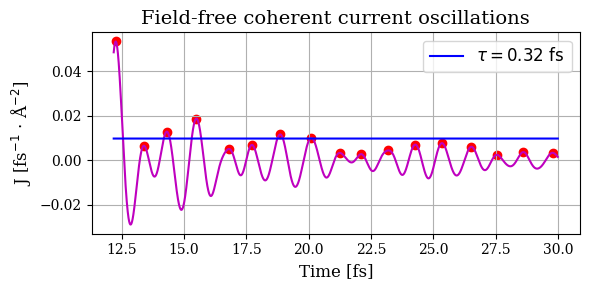

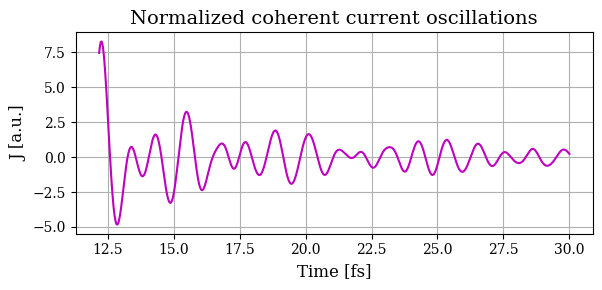

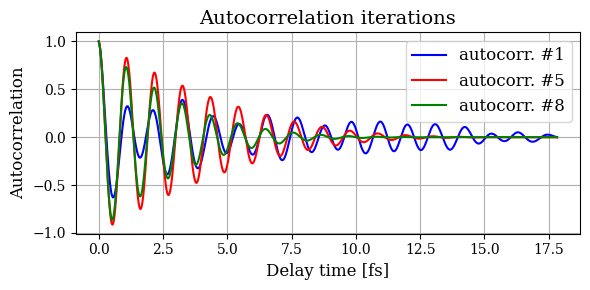

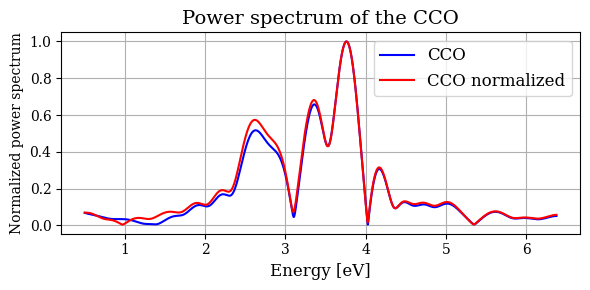

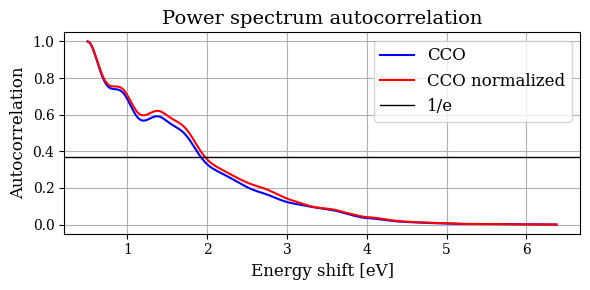

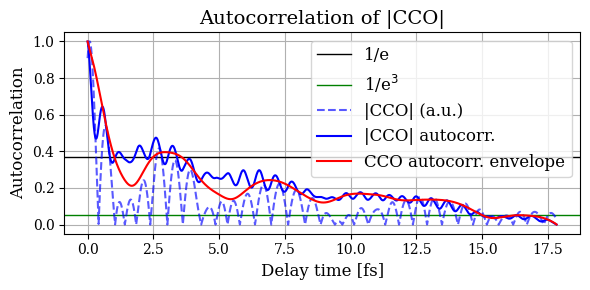

Error is:  3.1216089404499727
 


In [26]:
tau_fid_z_arr = []

auto_corr_mandels_coherence=[]

mandels_coherence_arr=[]
mandels_coherence_abs_v2_arr=[]

autocorr_fid_1_e_arr=[]
autocorr_fid_1_e_abs_v2=[]
autocorr_fid_3_e_arr=[]

normalized_fid_mandels_coherence=[]
normalized_fid_mandels_coherence_abs_v2=[]


eV_autocorrelation_fid=[]
eV_autocorrelation_normalized_fid=[]

eV_autocorrelation_fid_coherence_v2=[]
eV_autocorrelation_fid_normalized_coherence_v2=[]

j=0
for folder in sorted_folders:

    j=j+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2 - 250) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau)

    # ЭЭЭЭЭЭЭЭКСПЕРИМЕНТЫ
    # p0 = [0.02, 0, 20]

    # try:
    #     popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    # except RuntimeError:
    #     print("First fit failed, trying different initial guess...")
    
    #     p0_v2 = [0.05, 0, 6.65]
    #     popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0_v2)

    
    # j0, j_final, tau_pump= popt
    # j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)
    
    # # ratio = j_final/max(delta_Jm_x)
    
    # # # Разностный ток по x
    # # plt.plot(t, Jm_pump_z, color='m')
    # # if tau_pump<30:
    # #     plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
    # # else: plt.plot(t_array_cut, j_fit, '--', color='r')
    # # plt.xlabel('Time [fs]')
    # # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # # plt.title('Matter current density along z, only pump')
    # # plt.legend()
    # # plt.grid(True)
    # # plt.tight_layout()


    # interp_f = interp1d(t_array_cut, j_fit, kind="linear", fill_value="extrapolate")
    # # t_array_cut_full = np.linspace(t_array_cut[0], 30, 15000-m0_cut_4)    # сетка на [t1, t2]
    # j_fit_full = interp_f(t[m0_cut_4:])  
    
    
    # fid_signal = Jm_pump_z[m0_cut_4:]-j_fit_full

    fid_signal = Jm_pump_z[m0_cut_4:]
    
    fid_signal = fid_signal-moving_average_time(fid_signal, 0.002, 10)
        
    
    t_z_exp_fit = t[m0_cut_4:]
    # fid_z = Jm_pump_z[m0_cut_4:]-j_fit_full
    t_peaks_vals, fid_peak_vals = find_halfcycle_maxima(np.array(t_z_exp_fit), np.array(fid_signal))
    
    
    # fit peak points
    t_fit_vals = t_peaks_vals
    y_fit_vals = fid_peak_vals
    
    exclude_array=[]
    # exclude_array = [2, 3, 4]
    t_fit_vals = np.delete(t_fit_vals, exclude_array)
    y_fit_vals = np.delete(y_fit_vals, exclude_array)


    print("Points check: ")
    print(t_fit_vals)
    print(y_fit_vals)
    
    params, cov = fit_exp_gauss(t_fit_vals, y_fit_vals)
    
    A, tau_exp_z, t0, sigma, C = params

    print("Params: ", params)

    tau_fid_z_arr.append(tau_exp_z)
    
    # print("Fit parameters:")
    # print(f"A = {A}")
    # print(f"tau = {tau_exp_z}")
    # print(f"t0 = {t0}")
    # print(f"sigma = {sigma}")
    # print(f"C = {C}")
    
    # построение
    t_fit = t_z_exp_fit
    y_fit = exp_gauss(t_fit, *params)

    xticks_fontsize=10
    yticks_fontsize=10
    legend_fontsize=12
    
    title_fontsize=14
    xlabel_fontsize=12
    ylabel_fontsize=12
    
    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    
    
    plt.plot(t[m0_cut_4:], fid_signal, color='m')
    plt.scatter(t_peaks_vals, fid_peak_vals, color='r')
    plt.plot(t_fit, y_fit, color='b', label= rf"$\tau = {new_taus[j-1]:.2f}\ \mathrm{{fs}}$")
    plt.grid()
    plt.legend(fontsize=legend_fontsize)
    plt.xlabel('Time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('J [fs$^{-1}$ $\\cdot$ Å$^{-2}$]', fontsize=ylabel_fontsize)
    plt.title('Field-free coherent current oscillations', fontsize=title_fontsize)
    plt.tight_layout()

    
    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_fid_z_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " z-axis fid plots are completed")


    print(fid_peak_vals)
    print(C)
    
    normalized_fid_signal=fid_signal/(y_fit+max(fid_peak_vals[-4:])-C**2)
    normalized_fid_signal = normalized_fid_signal-moving_average_time(normalized_fid_signal, 0.002, 5)

    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    # plt.legend(fontsize=legend_fontsize)
    
    plt.plot(t[m0_cut_4:], normalized_fid_signal, color='m')
    plt.grid()
    plt.xlabel('Time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('J [a.u.]', fontsize=ylabel_fontsize)
    plt.title('Normalized coherent current oscillations', fontsize=title_fontsize)
    plt.tight_layout()

    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_normalized_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_normalized_fid_z_' + folder + ".pdf", bbox_inches="tight")
    


    print("Mandel's time fot fid normalized signal", coherence_time(normalized_fid_signal, 0.002))
    normalized_fid_mandels_coherence.append(coherence_time(normalized_fid_signal, 0.002))
    normalized_fid_mandels_coherence_abs_v2.append(coherence_time_v2_abs(normalized_fid_signal, 0.002))

    
    
    each_num=5
    
    fid_data_array=np.array([  t[m0_cut_4:][::each_num], fid_signal[::each_num], y_fit[::each_num], normalized_fid_signal[::each_num]  ])
    
    columns = ["time",  "fid_signal", "fid_exp_fit", "normalized_fid"]
    df = pd.DataFrame(fid_data_array.T, columns=columns)
    
    
    df.to_csv("fid_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", index=False)
    
    with open("fid_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", "w") as f:
        f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " z-axis fid data saving in csv format is completed")

    print("Mandel's coherence time:", coherence_time(np.array(fid_signal), 0.002))
    mandels_coherence_arr.append(coherence_time(np.array(fid_signal), 0.002))
    mandels_coherence_abs_v2_arr.append(coherence_time_v2_abs(fid_signal, 0.002))


    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)

    plt.grid()
    plt.xlabel('Delay time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('Autocorrelation', fontsize=ylabel_fontsize)
    plt.title('Autocorrelation iterations', fontsize=title_fontsize)
    

    
    auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    colors=['b', 'olive', 'r', 'g', 'm', 'orange', 'gold', 'purple', 'slateblue', 'navy', 'darkred']
    
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], auto_corr, label="autocorr. #1", color=colors[0])

    num_auto_corr_iters=10
    auto_corr_coh_vals=[]
    for i in range(num_auto_corr_iters):
    
        new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
        new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
        new_auto_corr = new_auto_corr / new_auto_corr[0]
        
        auto_corr=new_auto_corr

        print(coherence_time(auto_corr, 0.002))
        
        auto_corr_coh_vals.append(coherence_time(auto_corr, 0.002))
    
        if i!=0 and i%(3)==0 and i//3 < 3:
            plt.plot(t[m0_cut_4:]-t[m0_cut_4], new_auto_corr, label= rf"autocorr. #{int(i+2)}", color=colors[int(i//3+1)])

    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)

    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".pdf", bbox_inches="tight")
    
    auto_corr_mandels_coherence.append(max(auto_corr_coh_vals))
    # auto_corr_mandels_coherence.append(coherence_time(auto_corr, 0.002))


    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    
    
    plt.grid()
    plt.title('Power spectrum of the CCO', fontsize=title_fontsize)

    plt.xlabel("Energy [eV]", fontsize=xlabel_fontsize)
    plt.ylabel("Normalized power spectrum", fontsize=ylabel_fontsize-2)
    
    # second variable is convolve parameter val in eV
    F_ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=100, window="tukey", tukey_alpha=0.4)

    i_eV = int(np.where(F_ens > 0.5)[0][0])
    
    plt.plot(F_ens[i_eV:], F_fid[i_eV:], color='b', label='CCO')
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)  
    F_ens, F_fid_normalized = fourier_plot_window(normalized_fid_signal, 0.1, M=100, window="tukey", tukey_alpha=0.4)
    plt.plot(F_ens[i_eV:], F_fid_normalized[i_eV:], color='r', label='CCO normalized')
    
    plt.legend(fontsize=legend_fontsize)

    plt.tight_layout()


    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".pdf", bbox_inches="tight")



    spectral_intensity_data=np.array([F_ens, F_fid, F_fid_normalized])

    columns = ["energies",  "F_fid", "F_fid_normalized"]
    df = pd.DataFrame(spectral_intensity_data.T, columns=columns)
    
    df.to_csv("fid_data/fid/z/data/" + str(j) + "_spectral_intensity_" + folder + ".csv", index=False)
    
    with open("fid_data/fid/z/data/" + str(j) + "_spectral_intensity_" + folder + ".csv", "w") as f:
        f.write(r"# Units: Energy [eV], Spectral intensity [normalized] " + "\n")
        df.to_csv(f, index=False)


    
    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)


    plt.grid()
    plt.title('Power spectrum autocorrelation', fontsize=title_fontsize)

    plt.xlabel("Energy shift [eV]", fontsize=xlabel_fontsize)
    plt.ylabel("Autocorrelation", fontsize=ylabel_fontsize)

    auto_corr = np.correlate(F_fid[i_eV:], F_fid[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(F_fid[i_eV:])-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    i_0 = np.where(auto_corr < 0.369)[0][0]
    print("Spectrum autocorrelation time: ")
    print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    plt.plot(F_ens[i_eV:], auto_corr, color='b', label='CCO')

    eV_autocorrelation_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    eV_autocorrelation_fid_coherence_v2.append(coherence_time_v2_abs(F_fid[i_eV:], F_ens[1]-F_ens[0]))


    auto_corr = np.correlate(F_fid_normalized[i_eV:], F_fid_normalized[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(F_fid_normalized[i_eV:])-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    i_0 = np.where(auto_corr < 0.369)[0][0]
    print("Spectrum autocorrelation time: ")
    print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    plt.plot(F_ens[i_eV:], auto_corr, color='r', label='CCO normalized')

    eV_autocorrelation_normalized_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    eV_autocorrelation_fid_normalized_coherence_v2.append(coherence_time_v2_abs(F_fid_normalized[i_eV:], F_ens[1]-F_ens[0]))

    
    plt.axhline(y=0.369, color='black', label=rf"1/e", linewidth=1)
    plt.legend(fontsize=legend_fontsize)
    plt.tight_layout()

    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_spectral_intensity_autocorrelation_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_spectral_intensity_autocorrelation_fid_z_' + folder + ".pdf", bbox_inches="tight")
    


    

    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    

    plt.grid()
    plt.title('Autocorrelation of |CCO|', fontsize=title_fontsize)

    plt.xlabel("Delay time [fs]", fontsize=xlabel_fontsize)
    plt.ylabel("Autocorrelation", fontsize=ylabel_fontsize)
    
    auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    
    plt.axhline(y=0.369, color='black', label = rf"1/e", linewidth=1)
    plt.axhline(y=0.05, color='g', label = rf"1/e$^{3}$", linewidth=1)

    plt.plot(t[m0_cut_4:]-t[m0_cut_4], abs(fid_signal)/max(abs(fid_signal)), color='b', linestyle='--', alpha=0.65, label='|CCO| (a.u.)')
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], auto_corr, color='b', label='|CCO| autocorr.')
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], get_autocorr_envelope(np.array(fid_signal), 0.002), color='r', label='CCO autocorr. envelope')
    

    plt.legend(fontsize=legend_fontsize)

    i_1 = np.where(auto_corr < 0.369)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
    
    i_2 = np.where(auto_corr < 0.05)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])

    autocorr_fid_1_e_arr.append(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])


    
    i_1_v2_abs = np.where(get_autocorr_envelope(np.array(fid_signal), 0.002) < 0.369)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
    autocorr_fid_1_e_abs_v2.append(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
    

    
    autocorr_fid_3_e_arr.append(  (np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])/3  )

    plt.tight_layout()


    plt.savefig("fid_data/fid/z/ims/png/" + str(j)+ '_autocorrelation_of_abs_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("fid_data/fid/z/ims/pdf/" + str(j)+ '_autocorrelation_of_abs_fid_z_' + folder + ".pdf", bbox_inches="tight")


    plt.show()
    plt.close()


    
delta_1_tau_arr = 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence) - 1/np.array(mandels_coherence_arr)
print("Error is: ", np.sum(abs(delta_1_tau_arr)))
    

print(" ")

In [27]:
# print(np.array(eV_autocorrelation_fid)-np.array(eV_autocorrelation_fid_coherence_v2))
# # print(eV_autocorrelation_fid_coherence_v2)

# # print(eV_autocorrelation_normalized_fid)
# print(np.array(eV_autocorrelation_fid_normalized_coherence_v2)-np.array(eV_autocorrelation_normalized_fid))

In [28]:
def l2_normalize(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    a = np.dot(x, y) / np.dot(x, x)
    return a, a*x